# Importacoes

In [23]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric, plot_yearly

import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Ajuste do Dataset

In [24]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

df = pd.concat([df, df])

new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

df.columns = ["ds", "y1", "y", "y3", "y4", "y5"]

# Modelo com train/test

In [25]:
train = df.iloc[:80]
test = df.iloc[79:]

m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=160)

m.fit(train)
future = m.make_future_dataframe(periods=10,freq='MS')
forecast = m.predict(future)

09:24:40 - cmdstanpy - INFO - Chain [1] start processing
09:24:41 - cmdstanpy - INFO - Chain [1] done processing


<Axes: xlabel='ds'>

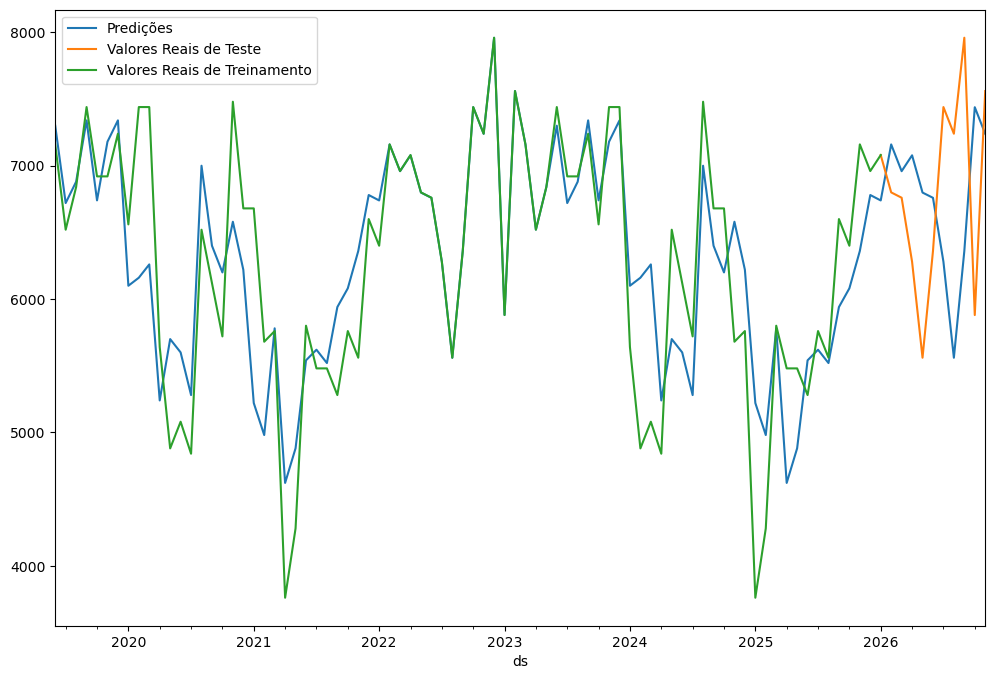

In [26]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
test.plot(x='ds',y='y',label='Valores Reais de Teste',legend=True,ax=ax)
train.plot(x='ds',y='y',label='Valores Reais de Treinamento',legend=True,ax=ax)

In [27]:
df_cv = cross_validation(m,initial="2190 days",period="30 days",horizon="60 days",parallel="processes")

09:24:41 - cmdstanpy - INFO - Chain [1] start processing
09:24:41 - cmdstanpy - INFO - Chain [1] start processing
09:24:41 - cmdstanpy - INFO - Chain [1] start processing
09:24:41 - cmdstanpy - INFO - Chain [1] start processing
09:24:41 - cmdstanpy - INFO - Chain [1] start processing
09:24:41 - cmdstanpy - INFO - Chain [1] start processing
09:24:43 - cmdstanpy - INFO - Chain [1] done processing
09:24:43 - cmdstanpy - INFO - Chain [1] done processing
09:24:43 - cmdstanpy - INFO - Chain [1] done processing
09:24:43 - cmdstanpy - INFO - Chain [1] done processing
09:24:46 - cmdstanpy - INFO - Chain [1] done processing
09:24:52 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,26 days,7.828417e+04,279.793077,279.793077,0.048575,0.048575,0.049784,1.0
1,27 days,6.360824e+03,79.754774,79.754774,0.014344,0.014344,0.014448,1.0
2,28 days,1.073375e+06,1036.038249,978.634487,0.149790,0.149790,0.163497,0.5
3,29 days,1.342320e+06,1158.585551,978.897188,0.137438,0.137438,0.152150,0.5
4,57 days,6.358454e+03,79.739912,79.739912,0.014342,0.014342,0.014445,1.0
5,58 days,1.071347e+06,1035.059023,976.675265,0.149482,0.149482,0.163163,0.0
6,59 days,1.342288e+06,1158.571587,978.914472,0.137441,0.137441,0.152153,0.5
7,60 days,4.633318e+05,680.684795,680.684795,0.096142,0.096142,0.100997,0.0


O modelo se torna eficiente após um dataset de 2 anos.

# Modelo sem train/test

In [29]:
df.columns = ["ds", "y1", "y", "y3", "y4", "y5"]

In [30]:
m = Prophet(growth='flat',yearly_seasonality=160)

m.fit(df)

future = m.make_future_dataframe(periods=48,freq='MS')

forecast = m.predict(future)

09:24:52 - cmdstanpy - INFO - Chain [1] start processing
09:24:54 - cmdstanpy - INFO - Chain [1] done processing


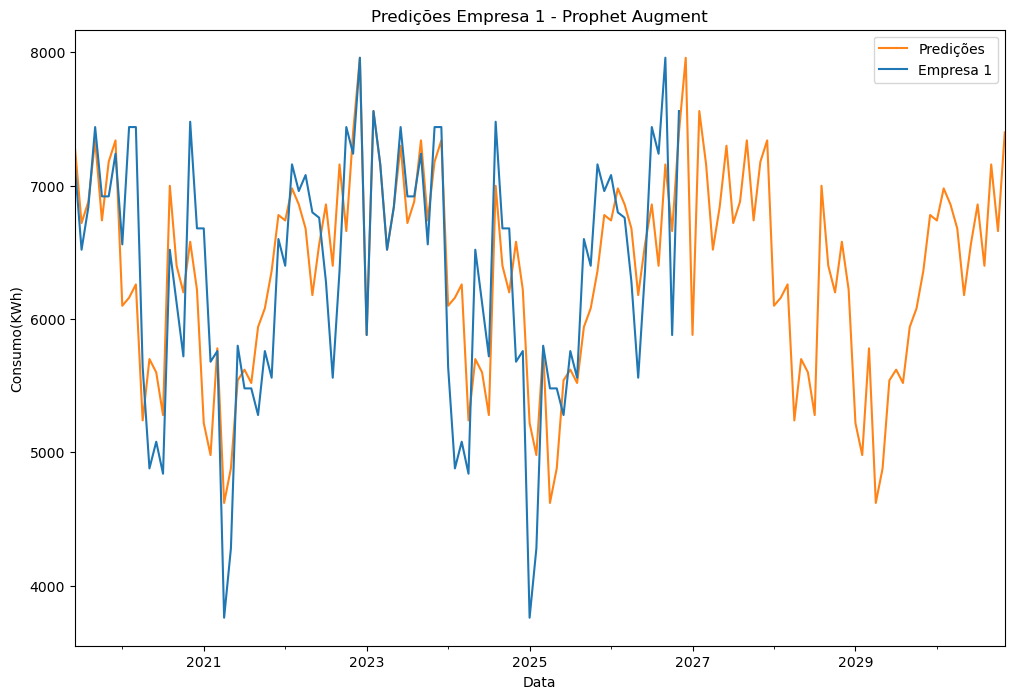

In [31]:
ax = forecast.plot(x='ds', y='yhat', label='Predições',legend=True, figsize=(12,8),color="#ff8316",title="Predições Empresa 1 - Prophet Augment",ylabel="Consumo(KWh)")
df.plot(x='ds',y='y',label='Empresa 1',legend=True,ax=ax,xlabel="Data")
plt.savefig("Prophet Augment - Empresa1pred.png")

In [32]:
df_cv = cross_validation(m,initial="2190 days",period="180 days",horizon="365 days",parallel="processes")

09:24:54 - cmdstanpy - INFO - Chain [1] start processing
09:24:56 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,30 days,1.289921e+05,359.154681,359.154681,0.051603,0.051603,0.052969,1.0
1,61 days,4.633318e+05,680.684795,680.684795,0.096142,0.096142,0.100997,1.0
2,92 days,1.294422e+05,359.780753,359.780753,0.052909,0.052909,0.051545,1.0
3,120 days,3.959244e+04,198.978489,198.978489,0.029435,0.029435,0.029008,1.0
4,151 days,6.369952e+05,798.119769,798.119769,0.127089,0.127089,0.119496,0.0
5,181 days,1.534303e+06,1238.670031,1238.670031,0.222782,0.222782,0.200454,0.0
6,212 days,1.594291e+05,399.285695,399.285695,0.062781,0.062781,0.060870,1.0
7,242 days,1.345773e+06,1160.074403,1160.074403,0.155924,0.155924,0.169108,0.0
8,273 days,2.823065e+06,1680.197761,1680.197761,0.232072,0.232072,0.262535,0.0
9,304 days,2.559929e+06,1599.977725,1599.977725,0.201002,0.201002,0.223460,0.0
